<a href="https://colab.research.google.com/github/Abhinavks2006/GenerativeAI_Internship/blob/main/day_5_text_processing_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
# The previous file_path 'movie_reviews.csv' was not found in the dataset.
# A common file in the 'nltkdata/movie-review' dataset is 'movie_review.csv' (singular).
file_path = "movie_review.csv"

# Load the latest version
# Using kagglehub.dataset_load as recommended (load_dataset is deprecated).
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "nltkdata/movie-review",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

Using Colab cache for faster access to the 'movie-review' dataset.


In [35]:
df.head()

,fold_id,cv_tag,html_id,sent_id,text,tag,text_lowercase,text_tokens,text_tokens_cleaned,text_stemmed,text_lemmatized
0,0,cv000,29590,0,films adapted from comic books have had plenty...,pos,films adapted from comic books have had plenty...,"[films, adapted, from, comic, books, have, had...","[films, adapted, comic, books, plenty, success...","[film, adapt, comic, book, plenti, success, ,,...","[film, adapted, comic, book, plenty, success, ..."
1,0,cv000,29590,1,"for starters , it was created by alan moore ( ...",pos,"for starters , it was created by alan moore ( ...","[for, starters, ,, it, was, created, by, alan,...","[starters, ,, created, alan, moore, (, eddie, ...","[starter, ,, creat, alan, moor, (, eddi, campb...","[starter, ,, created, alan, moore, (, eddie, c..."
2,0,cv000,29590,2,to say moore and campbell thoroughly researche...,pos,to say moore and campbell thoroughly researche...,"[to, say, moore, and, campbell, thoroughly, re...","[say, moore, campbell, thoroughly, researched,...","[say, moor, campbel, thoroughli, research, sub...","[say, moore, campbell, thoroughly, researched,..."
3,0,cv000,29590,3,"the book ( or "" graphic novel , "" if you will ...",pos,"the book ( or "" graphic novel , "" if you will ...","[the, book, (, or, ``, graphic, novel, ,, ``, ...","[book, (, ``, graphic, novel, ,, ``, ), 500, p...","[book, (, ``, graphic, novel, ,, ``, ), 500, p...","[book, (, ``, graphic, novel, ,, ``, ), 500, p..."
4,0,cv000,29590,4,"in other words , don't dismiss this film becau...",pos,"in other words , don't dismiss this film becau...","[in, other, words, ,, do, n't, dismiss, this, ...","[words, ,, n't, dismiss, film, source, .]","[word, ,, n't, dismiss, film, sourc, .]","[word, ,, n't, dismiss, film, source, .]"


### Convert text to lowercase

In [29]:
df['text_lowercase'] = df['text'].str.lower()
display(df[['text', 'text_lowercase']].head())

,text,text_lowercase
0,films adapted from comic books have had plenty...,films adapted from comic books have had plenty...
1,"for starters , it was created by alan moore ( ...","for starters , it was created by alan moore ( ..."
2,to say moore and campbell thoroughly researche...,to say moore and campbell thoroughly researche...
3,"the book ( or "" graphic novel , "" if you will ...","the book ( or "" graphic novel , "" if you will ..."
4,"in other words , don't dismiss this film becau...","in other words , don't dismiss this film becau..."


### Tokenize text into words

In [30]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

df['text_tokens'] = df['text_lowercase'].apply(nltk.word_tokenize)
display(df[['text_lowercase', 'text_tokens']].head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,text_lowercase,text_tokens
0,films adapted from comic books have had plenty...,"[films, adapted, from, comic, books, have, had..."
1,"for starters , it was created by alan moore ( ...","[for, starters, ,, it, was, created, by, alan,..."
2,to say moore and campbell thoroughly researche...,"[to, say, moore, and, campbell, thoroughly, re..."
3,"the book ( or "" graphic novel , "" if you will ...","[the, book, (, or, ``, graphic, novel, ,, ``, ..."
4,"in other words , don't dismiss this film becau...","[in, other, words, ,, do, n't, dismiss, this, ..."


### Remove English Stopwords

In [31]:
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

df['text_tokens_cleaned'] = df['text_tokens'].apply(remove_stopwords)
display(df[['text_tokens', 'text_tokens_cleaned']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,text_tokens,text_tokens_cleaned
0,"[films, adapted, from, comic, books, have, had...","[films, adapted, comic, books, plenty, success..."
1,"[for, starters, ,, it, was, created, by, alan,...","[starters, ,, created, alan, moore, (, eddie, ..."
2,"[to, say, moore, and, campbell, thoroughly, re...","[say, moore, campbell, thoroughly, researched,..."
3,"[the, book, (, or, ``, graphic, novel, ,, ``, ...","[book, (, ``, graphic, novel, ,, ``, ), 500, p..."
4,"[in, other, words, ,, do, n't, dismiss, this, ...","[words, ,, n't, dismiss, film, source, .]"


### Apply Porter Stemmer

In [32]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

def stem_tokens(tokens):
    return [stemmer.stem(word) for word in tokens]

df['text_stemmed'] = df['text_tokens_cleaned'].apply(stem_tokens)
display(df[['text_tokens_cleaned', 'text_stemmed']].head(10))

,text_tokens_cleaned,text_stemmed
0,"[films, adapted, comic, books, plenty, success...","[film, adapt, comic, book, plenti, success, ,,..."
1,"[starters, ,, created, alan, moore, (, eddie, ...","[starter, ,, creat, alan, moor, (, eddi, campb..."
2,"[say, moore, campbell, thoroughly, researched,...","[say, moor, campbel, thoroughli, research, sub..."
3,"[book, (, ``, graphic, novel, ,, ``, ), 500, p...","[book, (, ``, graphic, novel, ,, ``, ), 500, p..."
4,"[words, ,, n't, dismiss, film, source, .]","[word, ,, n't, dismiss, film, sourc, .]"
5,"[get, past, whole, comic, book, thing, ,, migh...","[get, past, whole, comic, book, thing, ,, migh..."
6,"[getting, hughes, brothers, direct, seems, alm...","[get, hugh, brother, direct, seem, almost, lud..."
7,"[ghetto, question, ,, course, ,, whitechapel, ...","[ghetto, question, ,, cours, ,, whitechapel, 1..."
8,"['s, filthy, ,, sooty, place, whores, (, calle...","['s, filthi, ,, sooti, place, whore, (, call, ..."
9,"[first, stiff, turns, ,, copper, peter, godley...","[first, stiff, turn, ,, copper, peter, godley,..."


### Apply Lemmatization and Compare with Stemming

In [33]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df['text_lemmatized'] = df['text_tokens_cleaned'].apply(lemmatize_tokens)
display(df[['text_stemmed', 'text_lemmatized']].head(10))

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,text_stemmed,text_lemmatized
0,"[film, adapt, comic, book, plenti, success, ,,...","[film, adapted, comic, book, plenty, success, ..."
1,"[starter, ,, creat, alan, moor, (, eddi, campb...","[starter, ,, created, alan, moore, (, eddie, c..."
2,"[say, moor, campbel, thoroughli, research, sub...","[say, moore, campbell, thoroughly, researched,..."
3,"[book, (, ``, graphic, novel, ,, ``, ), 500, p...","[book, (, ``, graphic, novel, ,, ``, ), 500, p..."
4,"[word, ,, n't, dismiss, film, sourc, .]","[word, ,, n't, dismiss, film, source, .]"
5,"[get, past, whole, comic, book, thing, ,, migh...","[get, past, whole, comic, book, thing, ,, migh..."
6,"[get, hugh, brother, direct, seem, almost, lud...","[getting, hughes, brother, direct, seems, almo..."
7,"[ghetto, question, ,, cours, ,, whitechapel, 1...","[ghetto, question, ,, course, ,, whitechapel, ..."
8,"['s, filthi, ,, sooti, place, whore, (, call, ...","['s, filthy, ,, sooty, place, whore, (, called..."
9,"[first, stiff, turn, ,, copper, peter, godley,...","[first, stiff, turn, ,, copper, peter, godley,..."


### Implement CountVectorizer

In [37]:
from sklearn.feature_extraction.text import CountVectorizer

# Join the lemmatized tokens back into a string for CountVectorizer
df['text_lemmatized_str'] = df['text_lemmatized'].apply(lambda x: ' '.join(x))

# Initialize CountVectorizer
vectorizer = CountVectorizer()

# Fit and transform the lemmatized text
X = vectorizer.fit_transform(df['text_lemmatized_str'])

# Display vocabulary
print("\nVocabulary (first 20 items):\n", list(vectorizer.vocabulary_.items())[:20])

# Display feature names
print("\nFeature Names (first 20 items):\n", vectorizer.get_feature_names_out()[:20])

# Display the matrix (first 5 rows, first 5 columns)
print("\nCountVectorizer Matrix (first 5 rows, 5 columns):\n", X[:5, :5].toarray())

# Display the shape of the matrix
print("\nShape of the CountVectorizer Matrix:\n", X.shape)


Vocabulary (first 20 items):
 [('film', 11841), ('adapted', 983), ('comic', 6340), ('book', 3979), ('plenty', 23802), ('success', 30592), ('whether', 34720), ('re', 25429), ('superheroes', 30753), ('batman', 3045), ('superman', 30760), ('spawn', 29543), ('geared', 12975), ('toward', 32214), ('kid', 17489), ('casper', 5154), ('arthouse', 2194), ('crowd', 7497), ('ghost', 13135), ('world', 35133)]

Feature Names (first 20 items):
 ['00' '000' '0009f' '007' '00s' '03' '04' '05' '05425' '10' '100' '1000'
 '10000' '100m' '101' '102' '103' '104' '105' '106']

CountVectorizer Matrix (first 5 rows, 5 columns):
 [[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]

Shape of the CountVectorizer Matrix:
 (64720, 35584)


### Implement TfidfVectorizer

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer()

# Fit and transform the lemmatized text
X_tfidf = tfidf_vectorizer.fit_transform(df['text_lemmatized_str'])

# Display vocabulary (first 20 items)
print("\nVocabulary (first 20 items):\n", list(tfidf_vectorizer.vocabulary_.items())[:20])

# Display feature names (first 20 items)
print("\nFeature Names (first 20 items):\n", tfidf_vectorizer.get_feature_names_out()[:20])

# Display the TF-IDF matrix (first 5 rows, first 5 columns)
print("\nTF-IDF Matrix (first 5 rows, 5 columns):\n", X_tfidf[:5, :5].toarray())

# Display the shape of the TF-IDF matrix
print("\nShape of the TF-IDF Matrix:\n", X_tfidf.shape)


Vocabulary (first 20 items):
 [('film', 11841), ('adapted', 983), ('comic', 6340), ('book', 3979), ('plenty', 23802), ('success', 30592), ('whether', 34720), ('re', 25429), ('superheroes', 30753), ('batman', 3045), ('superman', 30760), ('spawn', 29543), ('geared', 12975), ('toward', 32214), ('kid', 17489), ('casper', 5154), ('arthouse', 2194), ('crowd', 7497), ('ghost', 13135), ('world', 35133)]

Feature Names (first 20 items):
 ['00' '000' '0009f' '007' '00s' '03' '04' '05' '05425' '10' '100' '1000'
 '10000' '100m' '101' '102' '103' '104' '105' '106']

TF-IDF Matrix (first 5 rows, 5 columns):
 [[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]

Shape of the TF-IDF Matrix:
 (64720, 35584)


### Generate and Display Word Cloud

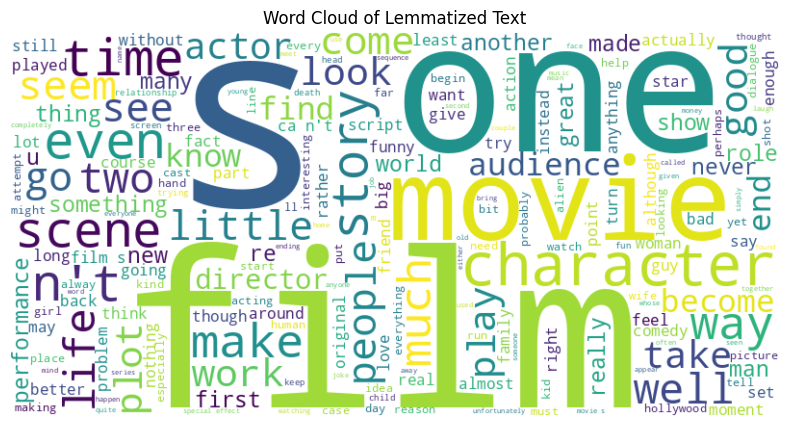

In [39]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all lemmatized text into a single string
all_words = ' '.join([text for text in df['text_lemmatized_str']])

# Generate Word Cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

# Display the generated image:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Lemmatized Text')
plt.show()